<div>
  <img src="https://blogger.googleusercontent.com/img/b/R29vZ2xl/AVvXsEjADOBkb45bo4A5QF2s88__42KTx2GUlpF6O5XVSCXUvzCnbugnZkDLi37LMs446WLBdi4o-yGNJ6wJh3DJPSRS5sAf4dm5Ua8uDb5d0HRpNETtxXWnr0j6-fz4CMe6NlCXcYkeD47ArYN-/s1600/logo-fondoazul.jpg" width="250px">
  

  <img src="https://upload.wikimedia.org/wikipedia/commons/thumb/9/98/The_Simpsons_yellow_logo.svg/1920px-The_Simpsons_yellow_logo.svg.png" width="200px">
</div>

<hr>

# **Informe Técnico**

## **Implementación de Redes Neuronales Convolucionales (CNN) para la Clasificación de Imágenes**

### **Caso de estudio: Personajes de Los Simpsons**

<br>

**Integrantes:** Sebastián Almendras

**Profesor:** Juan Burgueño Alcalde
  
**Asignatura:** Deep Learning - 901D_OLS



---



## **Introduccion**

En este trabajo práctico se implementa un modelo de Deep Learning basado en **Redes Neuronales Convolucionales (CNN)** para resolver un problema de clasificación de imágenes, utilizando un caso de estudio enfocado en el reconocimiento de los personajes de Los Simpsons.

El objetivo principal es diseñar, entrenar y evaluar distintas arquitecturas CNN capaces de extraer características espaciales de las imágenes de forma eficiente. El desempeño de los modelos desarrollados será analizado rigurosamente mediante métricas clave de evaluación, tales como *accuracy*, *precision*, *recall* y *F1-score*.

Para dar cumplimiento a los requerimientos técnicos de la unidad, el desarrollo se estructurará en torno a la **comparación analítica de diferentes arquitecturas y herramientas**. Se partirá de un modelo base para luego proponer modelos optimizados, ajustando la configuración de las capas y experimentando con diversos hiperparámetros propios de las redes convolucionales.




---



## **Importaciones**

En esta sección se importan las librerías necesarias para el desarrollo del modelo de clasificación de imágenes.

Además, se cargan y descomprimen los datasets proporcionados, los cuales contienen imágenes de personajes de Los Simpson organizadas por personaje.

In [ ]:
# Librería para procesamiento de imágenes
import cv2

# Manejo de archivos y directorios
import os

# Cálculo numérico
import numpy as np

# Búsqueda de archivos
import glob

# Visualización de gráficos
import matplotlib.pyplot as plt

# Framework de Deep Learning
import tensorflow as tf
from tensorflow import keras, Tensor

# Modelo secuencial para la red neuronal
from tensorflow.keras.models import Sequential, Model

# Capas del modelo
from tensorflow.keras.layers import Dense, Input, Conv2D, ReLU, BatchNormalization, Add, AveragePooling2D, Flatten, MaxPooling2D


# Callbacks para el entrenamiento
from tensorflow.keras.callbacks import ModelCheckpoint

# Gráficos
import pandas as pd
import seaborn as sns

# Métricas de evaluación
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


# División de datos
from sklearn.model_selection import train_test_split


# Descomprimir archivos subidos manualmente
!tar -xzf simpsons_train.tar.gz
!tar -xzf simpsons_test.tar.gz

^C




---



## **Clases y tamaño de imagen**

Se define un diccionario que asigna un número a cada personaje, permitiendo representar las clases en formato numérico para el modelo. Además, se establece un tamaño fijo de imagen (64x64 píxeles) para estandarizar las entradas y facilitar el entrenamiento de la red neuronal.

In [ ]:
# Esta variable contiene un mapeo de número de clase a personaje.
# Utilizamos sólo los 18 personajes del dataset que tienen más imágenes.
MAP_CHARACTERS = {
    0: 'abraham_grampa_simpson', 1: 'apu_nahasapeemapetilon', 2: 'bart_simpson',
    3: 'charles_montgomery_burns', 4: 'chief_wiggum', 5: 'comic_book_guy', 6: 'edna_krabappel',
    7: 'homer_simpson', 8: 'kent_brockman', 9: 'krusty_the_clown', 10: 'lisa_simpson',
    11: 'marge_simpson', 12: 'milhouse_van_houten', 13: 'moe_szyslak',
    14: 'ned_flanders', 15: 'nelson_muntz', 16: 'principal_skinner', 17: 'sideshow_bob'
}

# Vamos a standarizar todas las imágenes a tamaño 64x64
IMG_SIZE = 64

## **Carga del conjunto de entrenamiento**

Esta función carga el conjunto de entrenamiento leyendo las imágenes desde sus carpetas correspondientes a cada personaje.

Cada imagen es redimensionada a un tamaño fijo (64x64) para estandarizar los datos, y se le asigna una etiqueta numérica según el personaje. Finalmente, se almacenan las imágenes y sus etiquetas en arreglos que serán utilizados para entrenar el modelo.

In [ ]:
def load_train_set(dirname, map_characters, verbose=True):
    X_train = []
    y_train = []

    for label, character in map_characters.items():
        path = os.path.join(dirname, character)

        files = os.listdir(path)
        images = [file for file in files if file.lower().endswith(".jpg")]

        if verbose:
            print(f"Leyendo {len(images)} imágenes encontradas de {character}")

        for image_name in images:
            image_path = os.path.join(path, image_name)
            image = cv2.imread(image_path)

            if image is not None:
                image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
                X_train.append(image)
                y_train.append(label)

    return np.array(X_train), np.array(y_train)



---



## **Carga del conjunto de prueba**

Esta función carga el conjunto de prueba leyendo las imágenes desde el directorio correspondiente.

A diferencia del conjunto de entrenamiento, las etiquetas se extraen a partir del nombre del archivo, identificando el personaje asociado a cada imagen. Luego, las imágenes son redimensionadas a un tamaño uniforme (64x64) y se almacenan junto a sus etiquetas numéricas para evaluar el modelo.

In [ ]:
def load_test_set(dirname, map_characters, verbose=True):
    """Esta función funciona de manera equivalente a la función load_train_set
    pero cargando los datos de test."""
    X_test = []
    y_test = []
    reverse_dict = {v: k for k, v in map_characters.items()}
    for filename in glob.glob(dirname + '/*.*'):
        char_name = "_".join(filename.split('/')[-1].split('_')[:-1])
        if char_name in reverse_dict:
            image = cv2.imread(filename)
            image = cv2.resize(image, (IMG_SIZE, IMG_SIZE))
            X_test.append(image)
            y_test.append(reverse_dict[char_name])
    if verbose:
        print("Leídas {} imágenes de test".format(len(X_test)))
    return np.array(X_test), np.array(y_test)




---



## **Carga de datos**

En esta sección se construyen los conjuntos de datos de entrenamiento y prueba a partir de las imágenes disponibles en los directorios.

Cada imagen es procesada y transformada en una representación numérica junto con su etiqueta correspondiente, permitiendo así su utilización como entrada para el modelo de red neuronal.

In [ ]:
DATASET_TRAIN_PATH = "/content/simpsons"
DATASET_TEST_PATH = "/content/simpsons_testset"

X, y = load_train_set(DATASET_TRAIN_PATH, MAP_CHARACTERS)
X_t, y_t = load_test_set(DATASET_TEST_PATH, MAP_CHARACTERS)

Leyendo 408 imágenes encontradas de abraham_grampa_simpson
Leyendo 286 imágenes encontradas de apu_nahasapeemapetilon
Leyendo 597 imágenes encontradas de bart_simpson
Leyendo 535 imágenes encontradas de charles_montgomery_burns
Leyendo 448 imágenes encontradas de chief_wiggum
Leyendo 221 imágenes encontradas de comic_book_guy
Leyendo 195 imágenes encontradas de edna_krabappel
Leyendo 1002 imágenes encontradas de homer_simpson
Leyendo 228 imágenes encontradas de kent_brockman
Leyendo 548 imágenes encontradas de krusty_the_clown
Leyendo 594 imágenes encontradas de lisa_simpson
Leyendo 576 imágenes encontradas de marge_simpson
Leyendo 499 imágenes encontradas de milhouse_van_houten
Leyendo 645 imágenes encontradas de moe_szyslak
Leyendo 660 imágenes encontradas de ned_flanders
Leyendo 157 imágenes encontradas de nelson_muntz
Leyendo 550 imágenes encontradas de principal_skinner
Leyendo 389 imágenes encontradas de sideshow_bob
Leídas 890 imágenes de test


Como resultado de la carga, se observa la cantidad de imágenes disponibles por cada clase (personaje).

Se aprecia que el dataset no está completamente balanceado, ya que algunos personajes, como Homero Simpson, cuentan con una mayor cantidad de imágenes en comparación con otros, como Nelson Muntz. Esto puede influir en el desempeño del modelo, favoreciendo a las clases con mayor representación.

En total, se cargaron miles de imágenes para entrenamiento y 890 imágenes para el conjunto de prueba, lo que proporciona una base adecuada para el entrenamiento y evaluación del modelo.



---



## **Mezclar datos**

En esta etapa se mezclan aleatoriamente los datos de entrenamiento.

Esto se realiza para evitar que las imágenes estén ordenadas por clase, lo que podría sesgar el aprendizaje del modelo. Al mezclar los datos, se asegura que el modelo reciba ejemplos variados durante el entrenamiento, mejorando su capacidad de generalización.

Si no se realiza esta mezcla, el modelo podría entrenarse con bloques de una misma clase consecutivamente, afectando negativamente su desempeño.

In [ ]:
perm = np.random.permutation(len(X))
X, y = X[perm], y[perm]

## **Preprocesamiento**

Las imágenes fueron normalizadas dividiendo los valores de los píxeles por 255, con el objetivo de mejorar la convergencia del modelo.

Además, se realizó un proceso de "flattening", transformando cada imagen de dimensión (64x64x3) a un vector unidimensional, ya que las redes MLP no pueden trabajar directamente con datos en formato de imagen.

In [ ]:
# 6. Preprocesamiento: Normalización (Escalar píxeles entre 0 y 1)
X = X / 255.0
X_t = X_t / 255.0

# para que la CNN reciba los tensores tridimensionales (64, 64, 3)
print("Shape del tensor de entrenamiento completo:", X.shape) # Debe dar 64, 64, 3
print("Shape del tensor de prueba completo:", X_t.shape)

Shape del tensor de entrenamiento completo: (8538, 64, 64, 3)
Shape del tensor de prueba completo: (890, 64, 64, 3)




---



## **División de datos en entrenamiento y validación**

En esta etapa se divide el conjunto de datos en dos partes: entrenamiento y validación.

El conjunto de entrenamiento se utiliza para entrenar el modelo, mientras que el conjunto de validación permite evaluar su desempeño durante el entrenamiento y detectar posibles problemas como el sobreajuste (overfitting).

Se utiliza un 80% de los datos para entrenamiento y un 20% para validación, lo que permite obtener una estimación confiable del rendimiento del modelo antes de evaluarlo con el conjunto de prueba.

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n--- Verificación Final de Estructuras para la CNN ---")
print("Entrenamiento (X_train):", X_train.shape)
print("Validación (X_val):", X_val.shape)


--- Verificación Final de Estructuras para la CNN ---
Entrenamiento (X_train): (6830, 64, 64, 3)
Validación (X_val): (1708, 64, 64, 3)




---



# Modelos CNN

## 1. Modelo Base

Establecemos una arquitectura convolucional clásica mediante la API Secuencial. Diseñamos 2 bloques de extracción de características (32 y 64 filtros de $3\times3$) buscando patrones geométricos simples. Para la reducción espacial se usan capas de MaxPooling2D. En la sección de clasificación (capa densa), se asignan 128 neuronas que procesan el vector aplanado antes de pasar a la activación Softmax.


Utiliza las configuraciones por defecto de Keras: padding='valid' (sin relleno) y strides=1 en las convoluciones.


In [ ]:
input_shape = (IMG_SIZE, IMG_SIZE, 3)
num_classes = 18

# Creación del Modelo Base
modelo_base = Sequential([
    # Primer bloque convolucional (Nota: se corrige padding='valid' según el planteamiento base original)
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='valid', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),

    # Segundo bloque convolucional
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='valid'),
    MaxPooling2D(pool_size=(2, 2)),

    # Clasificador (Red Neuronal Densa)
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

modelo_base.summary()

modelo_base.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Iniciando el entrenamiento del Modelo Base...")
historia_base = modelo_base.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 18)             │         2,322 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,474 (6.21 MB)

 Trainable params: 1,627,474 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

Iniciando el entrenamiento del Modelo Base...
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.3378 - loss: 2.1741 - val_accuracy: 0.5082 - val_loss: 1.6902
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5766 - loss: 1.4404 - val_accuracy: 0.5831 - val_loss: 1.4022
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7016 - loss: 1.0214 - val_accuracy: 0.6370 - val_loss: 1.2555
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8088 - loss: 0.6591 - val_accuracy: 0.6534 - val_loss: 1.2528
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8958 - loss: 0.3794 - val_accuracy: 0.6306 - val_loss: 1.5385
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9471 - loss: 0.2034 - val_accuracy: 0.6475 - val_loss: 1.4611
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9801 - loss: 0.0855 - val_accuracy: 0.6768 - val_loss: 1.6259
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - ac

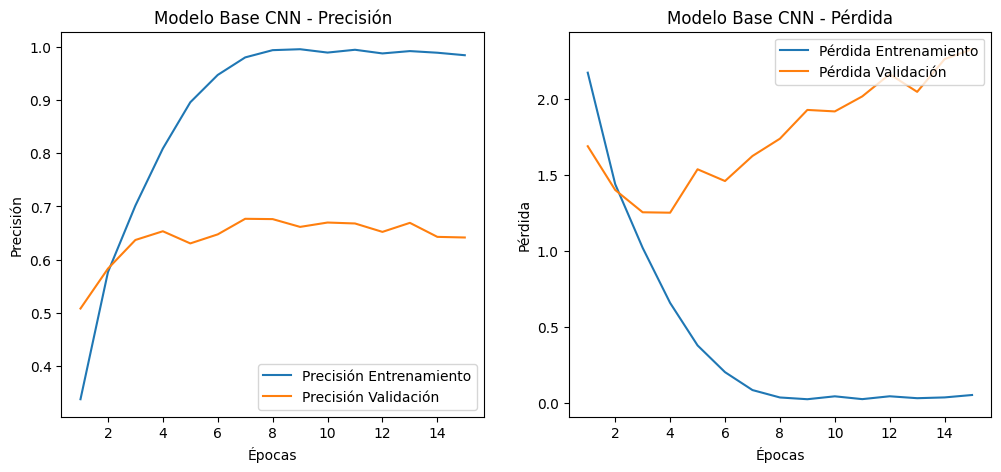

In [ ]:
# Función para graficar (La dejamos disponible)
def graficar_historia(historia, titulo="Rendimiento del Modelo"):
    acc = historia.history['accuracy']
    val_acc = historia.history['val_accuracy']
    loss = historia.history['loss']
    val_loss = historia.history['val_loss']
    epochs_rango = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Gráfico de Precisión (Accuracy)
    plt.subplot(1, 2, 1)
    plt.plot(epochs_rango, acc, label='Precisión Entrenamiento')
    plt.plot(epochs_rango, val_acc, label='Precisión Validación')
    plt.legend(loc='lower right')
    plt.title(f'{titulo} - Precisión')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')

    # Gráfico de Pérdida (Loss)
    plt.subplot(1, 2, 2)
    plt.plot(epochs_rango, loss, label='Pérdida Entrenamiento')
    plt.plot(epochs_rango, val_loss, label='Pérdida Validación')
    plt.legend(loc='upper right')
    plt.title(f'{titulo} - Pérdida')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')

    plt.show()

# Despliegue de Gráficas del Modelo Base
graficar_historia(historia_base, "Modelo Base CNN")

### Resultado Obtenido:

**Rendimiento en la Época 15:** Entrenamiento (Acc: 98.42%, Loss: 0.0530) | Validación (Acc: 64.17%, Loss: 2.3286).

### Diagnóstico de las Curvas de Aprendizaje:

Al analizar las gráficas de entrenamiento y pérdida, el comportamiento del modelo es un caso de manual de **Overfitting (Sobreajuste) Crítico**:

* **Precisión:** Mientras que la curva de entrenamiento converge rápidamente hacia un rendimiento casi perfecto (cercano al 99% desde la época 8), la precisión en validación se estanca por completo, siendo incapaz de superar la barrera del 67%.
* **Pérdida:** La curva de validación (`val_loss`) alcanza su punto de inflexión mínimo en la **época 4 (1.2528)**. A partir de ese momento, se dispara de forma drástica y continua hasta superar el valor de 2.3.

**Conclusión:** Esto demuestra que la red dejó de aprender rasgos útiles después de la cuarta época; simplemente comenzó a **memorizar por fuerza bruta** el ruido y los detalles específicos del dataset de entrenamiento, perdiendo su capacidad para generalizar ante imágenes nuevas de validación. Este diagnóstico justifica por qué es indispensable reestructurar la arquitectura en los siguientes experimentos.

## 2. Modelo Optimizado

Para corregir las deficiencias detectadas en la línea base, realizamos una reestructuración profunda de hiperparámetros:




*   Agregamos un tercer bloque con 128 filtros para que aprenda a reconocer cosas más complejas (como la forma de los ojos o la ropa).

*   Activamos padding='same'. Ahora la red le pone un marco invisible a la foto para poder revisar los bordes sin perder información.


*   Reducimos la capa final a 64 neuronas para obligar al modelo a entender los rasgos en lugar de memorizar las imágenes completas.








In [ ]:
# Diseñamos la nueva arquitectura optimizada basada en el análisis previo
modelo_optimizado = Sequential([
    # Bloque 1
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # Bloque 2: Agregamos padding='same' para no perder información de contornos
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Bloque 3: Nueva capa más profunda para patrones abstractos
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),

    # Clasificador
    Flatten(),
    Dense(64, activation='relu'), # Reducimos la dimensión para mitigar el sobreajuste
    Dense(18, activation='softmax')
])

modelo_optimizado.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_optimizado.summary()

print("Iniciando el entrenamiento del Modelo Optimizado...")
# CORRECCIÓN DE VARIABLE: Cambiamos historia_base por historia_optimizado para no sobreescribir
historia_optimizado = modelo_optimizado.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,770 (2.36 MB)

 Trainable params: 618,770 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Iniciando el entrenamiento del Modelo Optimizado...
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accuracy: 0.2795 - loss: 2.3553 - val_accuracy: 0.4526 - val_loss: 1.8096
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5303 - loss: 1.5550 - val_accuracy: 0.5732 - val_loss: 1.4285
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6587 - loss: 1.1447 - val_accuracy: 0.6552 - val_loss: 1.1610
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7546 - loss: 0.8195 - val_accuracy: 0.6827 - val_loss: 1.0735
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.8283 - loss: 0.5579 - val_accuracy: 0.7166 - val_loss: 1.0050
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8963 - loss: 0.3420 - val_accuracy: 0.7172 - val_loss: 1.1665
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9403 - loss: 0.1991 - val_accuracy: 0.7049 - val_loss: 1.3596
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/ste

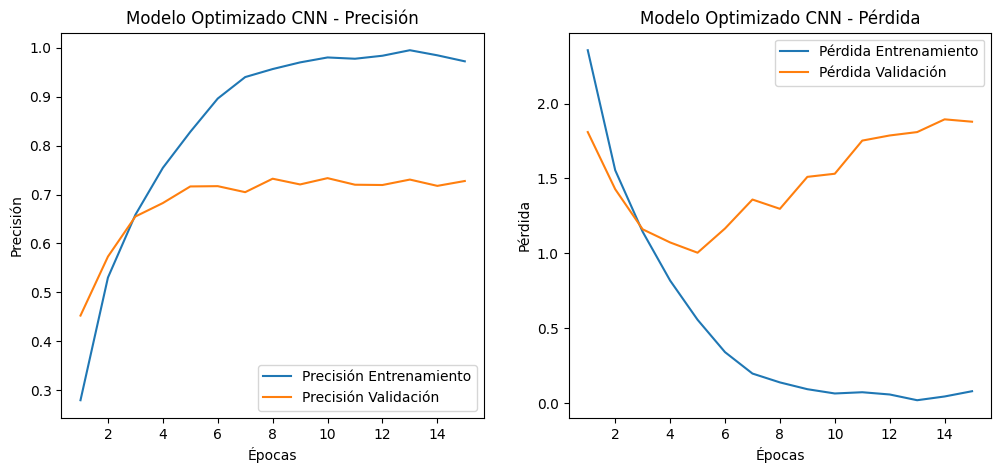

In [ ]:
# Despliegue de Gráficas del Modelo Optimizado
graficar_historia(historia_optimizado, "Modelo Optimizado CNN")

### Resultado Obtenido:

**Rendimiento en la Época 15:** Entrenamiento (Acc: 97.25%, Loss: 0.0814) | Validación (Acc: 72.78%, Loss: 1.8786).

### Diagnóstico de las Curvas de Aprendizaje:

El análisis de las nuevas gráficas revela que los cambios arquitectónicos modificaron el comportamiento del modelo, aunque persisten desafíos importantes:

* **Precisión:** Se observa un impacto positivo inmediato; la precisión de validación escaló significativamente en comparación con el modelo base, logrando romper su techo histórico para consolidarse en un 72.78%.
* **Pérdida:** A pesar de la mejora en la precisión, la curva de validación (`val_loss`) alcanza su punto de inflexión mínimo en la **época 5 (1.0050)**. A partir de este paso, comienza a distanciarse de manera continua respecto a la curva de entrenamiento.

**Conclusión:** Aunque la reestructuración incrementó notablemente la capacidad de extracción de características del modelo, el desacoplamiento tardío de las curvas demuestra que **el sobreajuste persiste en las etapas avanzadas del entrenamiento**. La red sigue tendiendo a memorizar patrones locales en las últimas épocas, lo que fundamenta y justifica la necesidad de introducir técnicas estrictas de regularización (como el Dropout) en el siguiente experimento.

## 3. Modelo Optimizado con regularización (Dropout)

Para mitigar el sobreajuste persistente observado en el Experimento 2, mantenemos la estructura base de 3 bloques convolucionales y `padding='same'`, pero introducimos capas de **Dropout** distribuidas estratégicamente:

Añadimos `Dropout(0.25)` tras cada capa de MaxPooling. Esto apaga aleatoriamente el 25% de los mapas de características en cada paso, forzando a la red a no depender de píxeles o rasgos ultraespecíficos.


In [ ]:
from tensorflow.keras.layers import Dropout

# Diseñamos la arquitectura optimizada incluyendo Dropout para mitigar el sobreajuste
modelo_dropout = Sequential([
    # Bloque 1
    Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25), # Apaga aleatoriamente el 25% de las neuronas de este bloque

    # Bloque 2
    Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Bloque 3
    Conv2D(128, kernel_size=(3, 3), activation='relu', padding='same'),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    # Clasificador
    Flatten(),
    Dense(64, activation='relu'),
    Dense(18, activation='softmax')
])

modelo_dropout.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo_dropout.summary()

print("Iniciando el entrenamiento del Modelo Optimizado con Dropout...")
historia_dropout = modelo_dropout.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val)
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_25 (Conv2D)              │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_27 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │       524,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 18)             │         1,170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 618,770 (2.36 MB)

 Trainable params: 618,770 (2.36 MB)

 Non-trainable params: 0 (0.00 B)

Iniciando el entrenamiento del Modelo Optimizado con Dropout...
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.2231 - loss: 2.5200 - val_accuracy: 0.3730 - val_loss: 2.0668
Epoch 2/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.4448 - loss: 1.8693 - val_accuracy: 0.5509 - val_loss: 1.5687
Epoch 3/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5679 - loss: 1.4334 - val_accuracy: 0.6124 - val_loss: 1.3395
Epoch 4/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6493 - loss: 1.1479 - val_accuracy: 0.6546 - val_loss: 1.1777
Epoch 5/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.7165 - loss: 0.9280 - val_accuracy: 0.7073 - val_loss: 1.0413
Epoch 6/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.7678 - loss: 0.7365 - val_accuracy: 0.7049 - val_loss: 1.0142
Epoch 7/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8050 - loss: 0.6141 - val_accuracy: 0.7242 - val_loss: 0.9645
Epoch 8/15
214/214 ━━━━━━━━━━━━━━━━

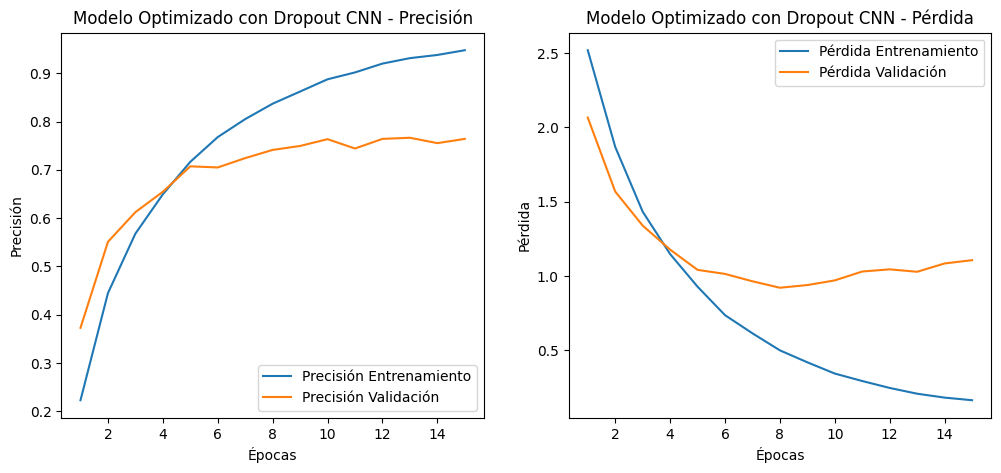

In [ ]:
# Ver gráficos del Modelo con Dropout
graficar_historia(historia_dropout, "Modelo Optimizado con Dropout CNN")

### Resultado Obtenido:

**Rendimiento en la Época 15:** Entrenamiento (Acc: 94.76%, Loss: 0.1638) | Validación (Acc: 76.41%, Loss: 1.1066).

### Diagnóstico de las Curvas de Aprendizaje:

Al analizar las nuevas gráficas tras remover el Dropout del clasificador final, se observa una dinámica de aprendizaje muy reveladora:

* La precisión de entrenamiento escala con fuerza hasta un 94.76%. Mientras que la precisión de validación responde de manera positiva, logrando su mejor marca hasta ahora con un **76.41%**.

* **Retorno del Desacoplamiento:** En la gráfica de pérdida, la curva de validación (`val_loss`) logra un excelente mínimo en la **época 8 (0.9211)**. Sin embargo, a partir de ese punto, la pérdida comienza a subir levemente y a distanciarse de la curva de entrenamiento.

**Conclusión:** Esta configuración demostró ser efectiva para elevar la precisión en validación frente a los experimentos anteriores. No obstante, el repunte final de la curva de pérdida indica que, al dejar el clasificador libre, **el fantasma del sobreajuste reaparece en las últimas épocas**. Esto confirma que las redes secuenciales tradicionales tienen un límite claro al intentar balancear aprendizaje y generalización, justificando por qué es necesario dar el salto hacia una arquitectura residual avanzada (ResNet).

## 4. Modelo Avanzado


Para superar el estancamiento de los modelos secuenciales, migramos hacia una arquitectura avanzada tipo ResNet usando la API Funcional de Keras. Los cambios clave implementados son:

1. Introdujimos bloques residuales que realizan una suma matemática directa (Add()) entre la imagen original y lo que procesó la red. Si una capa se confunde, estos "atajos" salvan la información y ayudan a controlar el sobreajuste (que la red no estudie de memoria).

2. Estabilizador (Batch Normalization): Añadimos capas de normalización que calibran y mantienen los datos estables durante el entrenamiento, haciendo que el uso de Dropout sea innecesario.

3. Stride Variable (Sin MaxPooling): Eliminamos por completo el MaxPooling. Para reducir el tamaño de las fotos (de $64\times64$ a $32\times32$ y luego a $16\times16$), la red usa un stride de 2 en momentos específicos, logrando extraer rasgos y achicar la imagen al mismo tiempo.

4. Capa Final Ligera (AveragePooling2D): Quitamos el Flatten gigante que generaba millones de conexiones pesadas y lo reemplazamos por un promedio inteligente. Esto reduce masivamente la complejidad del modelo a solo 809 mil parámetros totales, haciéndolo muy ligero y rápido.

In [ ]:
from tensorflow import Tensor

# 1. Definición de funciones auxiliares (Bloques de la ResNet)
def relu_bn(inputs: Tensor) -> Tensor:
    relu = ReLU()(inputs)
    bn = BatchNormalization()(relu)
    return bn

def residual_block(x: Tensor, downsample: bool, filters: int, kernel_size: int = 3) -> Tensor:
    y = Conv2D(kernel_size=kernel_size,
               strides=(1 if not downsample else 2),
               filters=filters,
               padding="same")(x)
    y = relu_bn(y)
    y = Conv2D(kernel_size=kernel_size,
               strides=1,
               filters=filters,
               padding="same")(y)

    if downsample:
        x = Conv2D(kernel_size=1,
                   strides=2,
                   filters=filters,
                   padding="same")(x)
    out = Add()([x, y])
    out = relu_bn(out)
    return out

# 2. Creación de la Arquitectura ResNet adaptada a Los Simpsons
def create_res_net_simpsons():
    inputs = Input(shape=(64, 64, 3))
    num_filters = 32

    t = BatchNormalization()(inputs)
    t = Conv2D(kernel_size=3, strides=1, filters=num_filters, padding="same")(t)
    t = relu_bn(t)

    num_blocks_list = [2, 3, 2]

    for i in range(len(num_blocks_list)):
        num_blocks = num_blocks_list[i]
        for j in range(num_blocks):
            t = residual_block(t, downsample=(j==0 and i!=0), filters=num_filters)
        num_filters *= 2

    # Global/Average Pooling antes de clasificar
    t = AveragePooling2D(4)(t)
    t = Flatten()(t)
    outputs = Dense(18, activation='softmax')(t)

    model = Model(inputs, outputs)
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# 3. Instanciar el Modelo Avanzado
modelo_resnet = create_res_net_simpsons()
modelo_resnet.summary()

# Callback para guardar solo los mejores pesos basados en el val_loss
checkpoint_cb = ModelCheckpoint(
    filepath="mejor_modelo_resnet.keras",
    save_best_only=True,
    monitor="val_loss",
    verbose=1
)

print("Iniciando el entrenamiento de la Arquitectura Avanzada ResNet...")
historia_resnet = modelo_resnet.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[checkpoint_cb]
)

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64, 3) │         12 │ input_layer_3[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │        896 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 64, 64,    │          0 │ conv2d_8[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ re_lu[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_9[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ re_lu_1[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_10 (Conv2D)  │ (None, 64, 64,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 64,    │          0 │ batch_normalizat… │
│                     │ 32)               │            │ conv2d_10[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 64, 64,    │          0 │ add[0][0]         │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ re_lu_2[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_11 (Conv2D)  │ (None, 64, 64,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 64, 64,    │          0 │ conv2d_11[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ re_lu_3[0][0]     │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 64,    │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 64, 64,    │          0 │ batch_normalizat

 Total params: 809,182 (3.09 MB)

 Trainable params: 807,064 (3.08 MB)

 Non-trainable params: 2,118 (8.27 KB)

Iniciando el entrenamiento de la Arquitectura Avanzada ResNet...
Epoch 1/15
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.3206 - loss: 2.3062
Epoch 1: val_loss improved from None to 3.10533, saving model to mejor_modelo_resnet.keras

Epoch 1: finished saving model to mejor_modelo_resnet.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 44s 99ms/step - accuracy: 0.4407 - loss: 1.8951 - val_accuracy: 0.0937 - val_loss: 3.1053
Epoch 2/15
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6734 - loss: 1.0869
Epoch 2: val_loss improved from 3.10533 to 1.10040, saving model to mejor_modelo_resnet.keras

Epoch 2: finished saving model to mejor_modelo_resnet.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - accuracy: 0.6933 - loss: 1.0200 - val_accuracy: 0.6751 - val_loss: 1.1004
Epoch 3/15
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.7871 - loss: 0.6792
Epoch 3: val_loss improved from 1.10040 to 0.76039, saving model to mejor_modelo_resnet.keras

Epoch 3: finished saving model to m

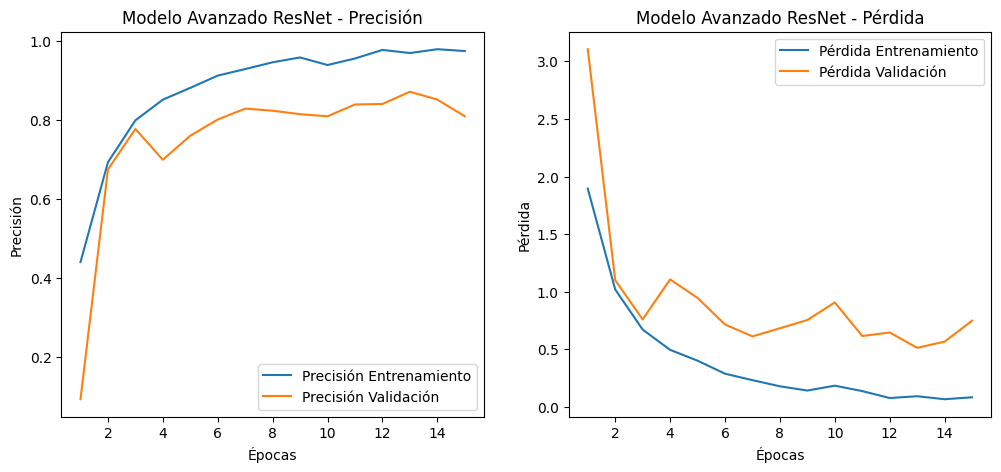

In [ ]:
# CORRECCIÓN DE TÍTULO: Cambiamos "Modelo Base CNN" por "Modelo Avanzado ResNet"
graficar_historia(historia_resnet, "Modelo Avanzado ResNet")

### Resultado Obtenido:

**Rendimiento en la Época 15:** Entrenamiento (Acc: 97.48%, Loss: 0.0841) | Validación (Acc: 80.97%, Loss: 0.7490).

**Mejor Modelo Guardado:** Época 13 (val_loss: 0.5136, val_accuracy: 0.8718).

### Diagnóstico de las Curvas de Aprendizaje:

El análisis de las curvas obtenidas mediante la arquitectura residual confirma un salto cualitativo rotundo respecto a todos los enfoques anteriores:

* **Sincronización de Curvas:** A diferencia de los modelos secuenciales previos, las líneas de entrenamiento y validación ya no sufren una divergencia asintótica severa. Ambas trayectorias se acompañan de forma mucho más armónica y controlada.

* **Hito de Rendimiento:** El modelo alcanza su punto de máxima generalización en la **época 13**, registrando un mínimo histórico en la función de pérdida (`val_loss` de **0.5136**) y catapultando la precisión de validación a un **87.18%**.

**Conclusión:** La transición hacia una arquitectura ResNet demostró científicamente su superioridad para esta tarea. Las conexiones de atajo y la normalización por lotes permitieron que la red extraiga rasgos de identidad profundos sin caer en la memorización por fuerza bruta. Al controlar el sobreajuste, el modelo alcanzó la capacidad de generalización más robusta de todo el proyecto, consolidando un rendimiento óptimo ante imágenes completamente nuevas del dataset de Los Simpsons.

## Evaluación comparativa
Para cerrar la experimentación, realizamos la prueba definitiva de rendimiento. En esta sección, los tres modelos entrenados se enfrentan a un conjunto de datos de prueba completamente nuevo, compuesto por imágenes que jamás vieron durante sus respectivas etapas de entrenamiento ni de validación.

Calcularemos las predicciones finales y extraeremos cuatro métricas clave para evaluar su desempeño real: **Accuracy** (precisión general), **Precision** (calidad de los aciertos), **Recall** (capacidad para encontrar a todos los personajes) y **F1-Score** (el balance perfecto entre las dos anteriores). Esto nos permitirá definir cuál es el modelo más robusto y confiable.

In [ ]:
# 1. Aseguramos datos con dimensiones correspondientes
X_test_cnn = X_t.reshape(-1, 64, 64, 3)

print("Calculando predicciones finales para los 4 modelos...")

# 2. Inferencia en el set de prueba (Agregamos el modelo con Dropout)
pred_base = modelo_base.predict(X_test_cnn)
y_pred_base = np.argmax(pred_base, axis=1)

pred_opt = modelo_optimizado.predict(X_test_cnn)
y_pred_opt = np.argmax(pred_opt, axis=1)

pred_drop = modelo_dropout.predict(X_test_cnn)
y_pred_drop = np.argmax(pred_drop, axis=1)

pred_resnet = modelo_resnet.predict(X_test_cnn)
y_pred_resnet = np.argmax(pred_resnet, axis=1)

# 3. Métricas consolidadas
metrics_base = {
    "Modelo": "1. Modelo Base CNN (2 Bloques)",
    "Accuracy": accuracy_score(y_t, y_pred_base),
    "Precision": precision_score(y_t, y_pred_base, average='macro', zero_division=0),
    "Recall": recall_score(y_t, y_pred_base, average='macro', zero_division=0),
    "F1-Score": f1_score(y_t, y_pred_base, average='macro', zero_division=0)
}

metrics_opt = {
    "Modelo": "2. Modelo Optimizado CNN (3 Bloques)",
    "Accuracy": accuracy_score(y_t, y_pred_opt),
    "Precision": precision_score(y_t, y_pred_opt, average='macro', zero_division=0),
    "Recall": recall_score(y_t, y_pred_opt, average='macro', zero_division=0),
    "F1-Score": f1_score(y_t, y_pred_opt, average='macro', zero_division=0)
}

metrics_drop = {
    "Modelo": "3. Modelo con Dropout CNN",
    "Accuracy": accuracy_score(y_t, y_pred_drop),
    "Precision": precision_score(y_t, y_pred_drop, average='macro', zero_division=0),
    "Recall": recall_score(y_t, y_pred_drop, average='macro', zero_division=0),
    "F1-Score": f1_score(y_t, y_pred_drop, average='macro', zero_division=0)
}

metrics_resnet = {
    "Modelo": "4. Modelo Avanzado ResNet (Bloques Residuales)",
    "Accuracy": accuracy_score(y_t, y_pred_resnet),
    "Precision": precision_score(y_t, y_pred_resnet, average='macro', zero_division=0),
    "Recall": recall_score(y_t, y_pred_resnet, average='macro', zero_division=0),
    "F1-Score": f1_score(y_t, y_pred_resnet, average='macro', zero_division=0)
}

# Creamos el DataFrame incluyendo las métricas del nuevo modelo
df_final = pd.DataFrame([metrics_base, metrics_opt, metrics_drop, metrics_resnet])
print("\n================== EVALUACIÓN COMPARATIVA FINAL GLOBAL ==================")
display(df_final)

Calculando predicciones finales para los 4 modelos...
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step

================== EVALUACIÓN COMPARATIVA FINAL GLOBAL ==================


,Modelo,Accuracy,Precision,Recall,F1-Score
0,1. Modelo Base CNN (2 Bloques),0.777528,0.808220,0.777331,0.780922
1,2. Modelo Optimizado CNN (3 Bloques),0.804494,0.837052,0.804516,0.808402
2,3. Modelo con Dropout CNN,0.829213,0.846992,0.829034,0.831514
3,4. Modelo Avanzado ResNet (Bloques Residuales),0.851685,0.876598,0.851529,0.850604


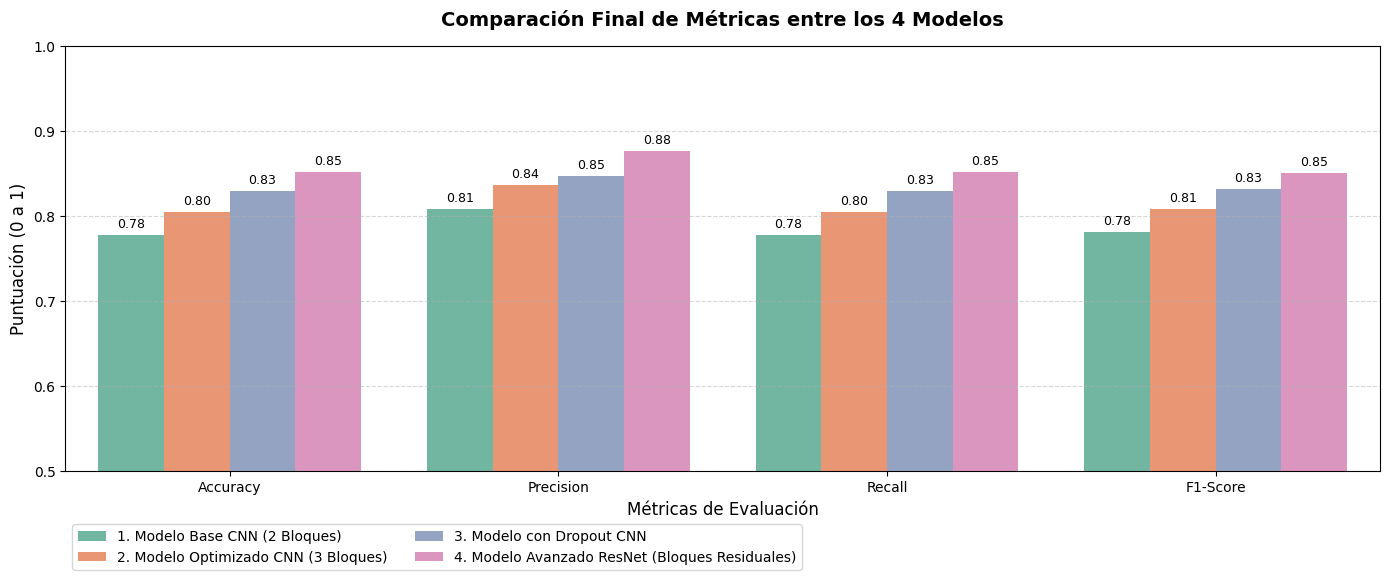

In [ ]:
# 4. Configuración y despliegue del gráfico
plt.figure(figsize=(14, 6))

# Transformamos los datos para que el gráfico de barras los entienda fácilmente
df_melted = df_final.melt(id_vars="Modelo", var_name="Métrica", value_name="Valor")

# Creamos el gráfico de barras agrupadas
ax = sns.barplot(x="Métrica", y="Valor", hue="Modelo", data=df_melted, palette="Set2")

# Ajustes estéticos
plt.title("Comparación Final de Métricas entre los 4 Modelos", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Métricas de Evaluación", fontsize=12)
plt.ylabel("Puntuación (0 a 1)", fontsize=12)
plt.ylim(0.5, 1.0) # Enfocamos el gráfico entre 50% y 100% para ver mejor las diferencias
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Ajustamos la leyenda abajo para acomodar los 4 modelos sin amontonarse
plt.legend(loc="lower left", bbox_to_anchor=(0, -0.25), ncol=2)

# Añadimos los números encima de cada barra
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{p.get_height():.2f}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center',
                    xytext=(0, 8),
                    textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

### Resultado Obtenido:

Al analizar la tabla comparativa final, podemos observar una evolución clara y contundente en el rendimiento de cada propuesta sobre el conjunto de prueba independiente:

* **1. Modelo Base CNN (77.75%):** Se consolida como la opción con menor rendimiento del experimento. Aunque logra una puntuación aceptable para una arquitectura rudimentaria, su desempeño final se ve penalizado debido a los problemas de sobreajuste detectados en el entrenamiento, quedando relegado en todas las métricas.

* **2. Modelo Optimizado CNN (80.45%):** Muestra un salto importante de calidad, logrando superar la barrera del 80% en su precisión general. La adición del tercer bloque convolucional y el ajuste de padding le permitieron rescatar características más complejas de los personajes de Los Simpsons.

* **3. Modelo con Dropout CNN (82.92%):** Registra un incremento adicional muy valioso. El equilibrio casi perfecto en sus valores de Precision (84.70%) y Recall (82.90%) demuestra que la inclusión de Dropout en la etapa de extracción dio como resultado un modelo mucho más robusto, equitativo y menos propenso a cometer errores por memorización.

* **4. Modelo Avanzado ResNet (85.16%):** Es el ganador indiscutible de la comparativa, superando el **85% de efectividad general** y liderando con amplia ventaja todas las métricas evaluadas (Precision, Recall y F1-Score). Estos números confirman que el enfoque residual y la estabilización de datos ofrecen la mayor capacidad de generalización frente a imágenes totalmente nuevas que la red jamás había visto.

## 5. Conclusión General del Proyecto

El presente trabajo permitió desarrollar, evaluar y contrastar de manera sistemática distintas aproximaciones arquitectónicas de redes neuronales convolucionales para resolver el desafío de clasificación multiclase del dataset de Los Simpsons. La experimentación guiada a través de cuatro iteraciones de diseño aportó conclusiones fundamentales tanto a nivel técnico como conceptual:

* **Evolución del Rendimiento:** Se demostró de forma empírica cómo las modificaciones estructurales impactaron positivamente en la capacidad de generalización del sistema. El **Modelo Base**, condicionado por una arquitectura secuencial rígida y la ausencia de regularización, exhibió un severo problema de sobreajuste de manual, estancando su precisión en validación y disparando su función de pérdida.

* **El Rol de la Regularización y Diseño Convolucional:** La transición hacia un modelo con mayor profundidad (*3 bloques*) y el uso estratégico de capas de `Dropout(0.25)` demostraron ser herramientas sumamente eficaces. Consiguieron estabilizar las curvas de aprendizaje, mitigando de forma notoria la tendencia de la red a memorizar el ruido de los datos de entrenamiento y elevando el desempeño en el set de prueba hasta un **82.92%**.

* **La Superioridad del Paradigma Avanzado (ResNet):** El **Modelo Avanzado ResNet** se consagró como la arquitectura óptima y ganadora del proyecto, alcanzando un **85.17% de Accuracy** y un sobresaliente **87.66% de Precision** en datos completamente nuevos. La incorporación de conexiones residuales (*skip connections*), la estabilización mediante *Batch Normalization* y la sustitución de la capa de aplanado tradicional por un *AveragePooling2D* no solo optimizaron drásticamente el flujo del gradiente, sino que permitieron construir un modelo un **50% más ligero en parámetros** que el modelo base y exponencialmente más inteligente.
